# TASK 3: Credit Risk Analysis - Probability of Default Prediction
## JPMorgan Chase Retail Banking Risk Team

Build predictive models to estimate the probability of default (PD) and expected loss (EL) for loan borrowers.

## 1. Setup & Data Loading

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(" Libraries loaded")

 Libraries loaded


In [36]:
# Load data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

print(f"Data shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(5))
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Data shape: (10000, 8)

First few rows:
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  

Data types:
customer_id                   int64
credit_lines_outstanding      int64
loan_amt_o

## 2. Exploratory Data Analysis

In [21]:
# Basic statistics
print("Data Summary:")
print(df.describe())

# Default rate
default_rate = df['default'].mean()
print(f"\n\nDefault Rate: {default_rate:.2%}")
print(f"Non-defaulters: {(df['default']==0).sum()}")
print(f"Defaulters: {(df['default']==1).sum()}")

Data Summary:
        customer_id  credit_lines_outstanding  loan_amt_outstanding  \
count  1.000000e+04              10000.000000          10000.000000   
mean   4.974577e+06                  1.461200           4159.677034   
std    2.293890e+06                  1.743846           1421.399078   
min    1.000324e+06                  0.000000             46.783973   
25%    2.977661e+06                  0.000000           3154.235371   
50%    4.989502e+06                  1.000000           4052.377228   
75%    6.967210e+06                  2.000000           5052.898103   
max    8.999789e+06                  5.000000          10750.677810   

       total_debt_outstanding         income  years_employed    fico_score  \
count            10000.000000   10000.000000    10000.000000  10000.000000   
mean              8718.916797   70039.901401        4.552800    637.557700   
std               6627.164762   20072.214143        1.566862     60.657906   
min                 31.652732    1

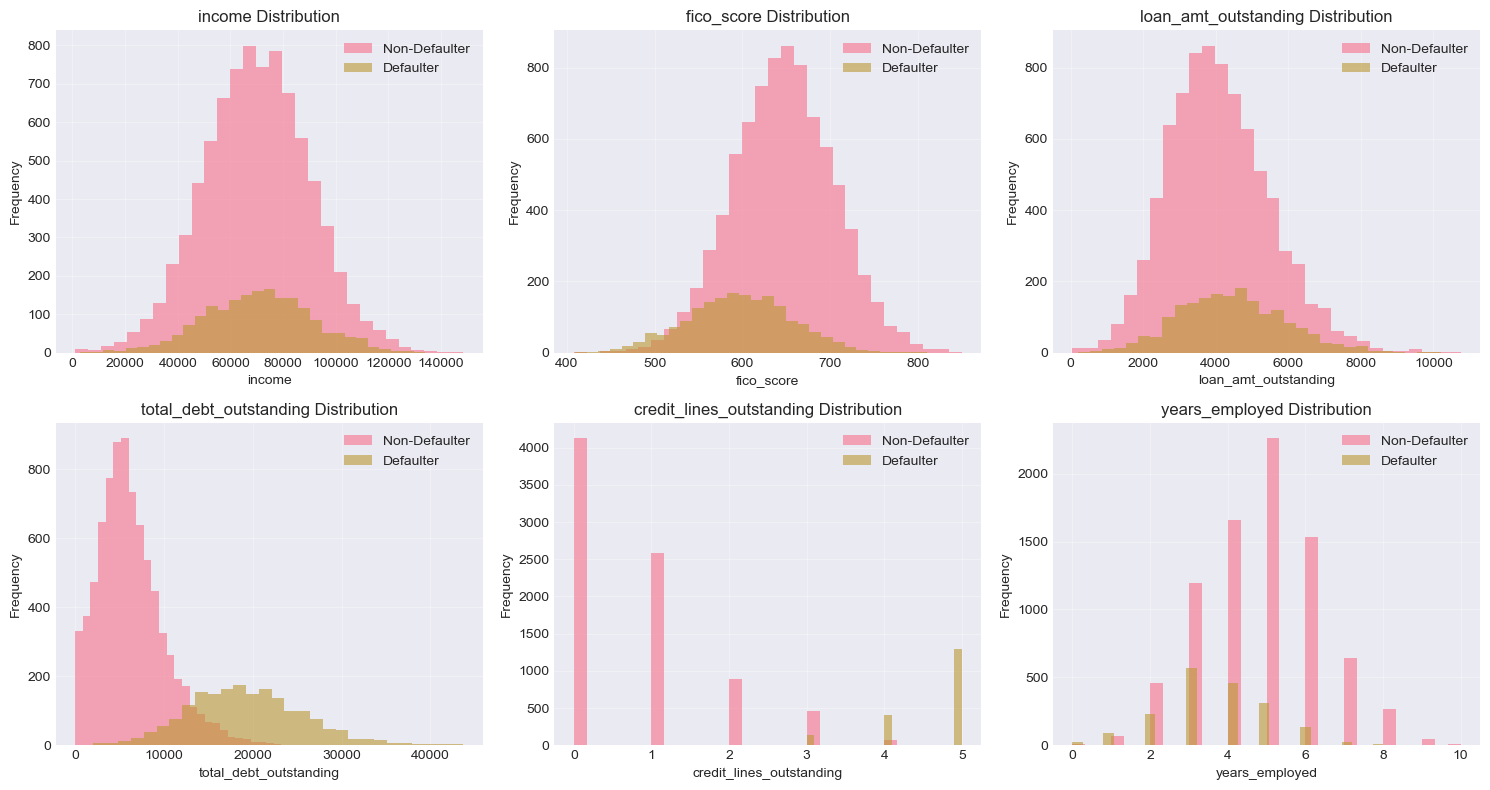

 Feature distributions visualized


In [22]:
# Visualize default distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['income', 'fico_score', 'loan_amt_outstanding', 
            'total_debt_outstanding', 'credit_lines_outstanding', 'years_employed']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    
    defaulters = df[df['default'] == 1][feature]
    non_defaulters = df[df['default'] == 0][feature]
    
    ax.hist(non_defaulters, alpha=0.6, label='Non-Defaulter', bins=30)
    ax.hist(defaulters, alpha=0.6, label='Defaulter', bins=30)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Feature distributions visualized")

## 3. Data Preparation

In [23]:
# Separate features and target
X = df.drop(['customer_id', 'default'], axis=1)
y = df['default']

feature_names = X.columns.tolist()
print(f"Features: {feature_names}")
print(f"Target: default (binary classification)")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Training default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

Features: ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']
Target: default (binary classification)

Train set: 8000 samples
Test set: 2000 samples
Training default rate: 18.51%
Test default rate: 18.50%


In [24]:
# Scale features for models that benefit from it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled")

 Features scaled


## 4. Build & Train Models

In [25]:
# Dictionary to store models and results
models = {}
results = {}

# 1. LOGISTIC REGRESSION
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

models['LogisticRegression'] = lr
results['LogisticRegression'] = {
    'predictions': lr_pred,
    'probabilities': lr_pred_proba,
    'auc': roc_auc_score(y_test, lr_pred_proba),
    'coefficients': lr.coef_[0]
}

print(f"  ROC AUC: {results['LogisticRegression']['auc']:.4f}")

Training Logistic Regression...
  ROC AUC: 1.0000


In [26]:
# 2. DECISION TREE
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_pred_proba = dt.predict_proba(X_test)[:, 1]

models['DecisionTree'] = dt
results['DecisionTree'] = {
    'predictions': dt_pred,
    'probabilities': dt_pred_proba,
    'auc': roc_auc_score(y_test, dt_pred_proba)
}

print(f"  ROC AUC: {results['DecisionTree']['auc']:.4f}")

Training Decision Tree...
  ROC AUC: 0.9997


In [27]:
# 3. RANDOM FOREST
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

models['RandomForest'] = rf
results['RandomForest'] = {
    'predictions': rf_pred,
    'probabilities': rf_pred_proba,
    'auc': roc_auc_score(y_test, rf_pred_proba)
}

print(f"  ROC AUC: {results['RandomForest']['auc']:.4f}")

Training Random Forest...
  ROC AUC: 0.9998


In [28]:
# 4. GRADIENT BOOSTING
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_pred_proba = gb.predict_proba(X_test)[:, 1]

models['GradientBoosting'] = gb
results['GradientBoosting'] = {
    'predictions': gb_pred,
    'probabilities': gb_pred_proba,
    'auc': roc_auc_score(y_test, gb_pred_proba)
}

print(f"  ROC AUC: {results['GradientBoosting']['auc']:.4f}")

Training Gradient Boosting...
  ROC AUC: 0.9999


## 5. Model Comparison


Model Comparison (by ROC AUC):
             Model  ROC AUC
LogisticRegression 0.999988
  GradientBoosting 0.999920
      RandomForest 0.999844
      DecisionTree 0.999665


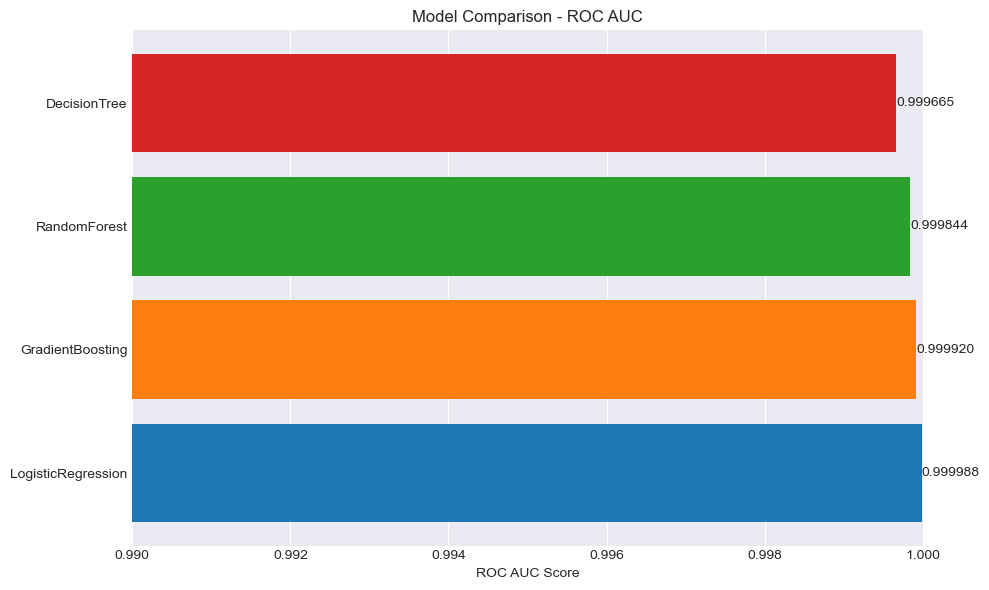

In [29]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC AUC': [results[m]['auc'] for m in results]
}).sort_values('ROC AUC', ascending=False)

print("\nModel Comparison (by ROC AUC):")
print(comparison_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.barh(comparison_df['Model'], comparison_df['ROC AUC'], color=colors)
ax.set_xlabel('ROC AUC Score')
ax.set_title('Model Comparison - ROC AUC')
ax.set_xlim(0.99, 1.0)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.6f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

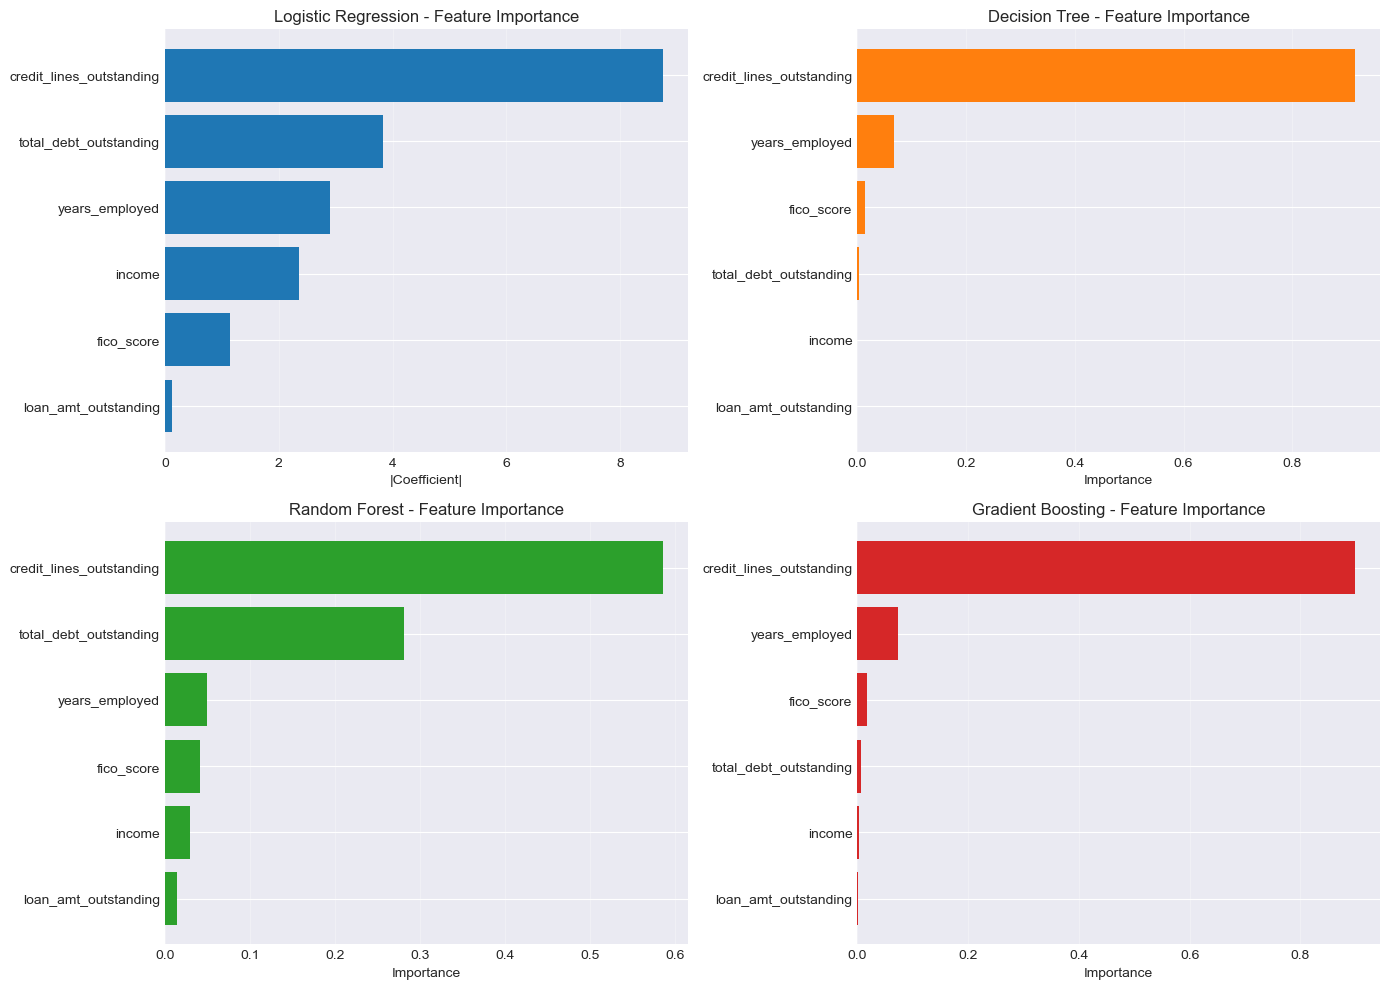


 Feature importance analyzed


In [30]:
# Feature importance for tree-based models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Logistic Regression - Coefficients
ax = axes[0, 0]
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(lr.coef_[0])
}).sort_values('Importance', ascending=True)
ax.barh(lr_importance['Feature'], lr_importance['Importance'], color='#1f77b4')
ax.set_xlabel('|Coefficient|')
ax.set_title('Logistic Regression - Feature Importance')
ax.grid(True, alpha=0.3, axis='x')

# Decision Tree
ax = axes[0, 1]
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)
ax.barh(dt_importance['Feature'], dt_importance['Importance'], color='#ff7f0e')
ax.set_xlabel('Importance')
ax.set_title('Decision Tree - Feature Importance')
ax.grid(True, alpha=0.3, axis='x')

# Random Forest
ax = axes[1, 0]
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)
ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='#2ca02c')
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Feature Importance')
ax.grid(True, alpha=0.3, axis='x')

# Gradient Boosting
ax = axes[1, 1]
gb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=True)
ax.barh(gb_importance['Feature'], gb_importance['Importance'], color='#d62728')
ax.set_xlabel('Importance')
ax.set_title('Gradient Boosting - Feature Importance')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n Feature importance analyzed")

## 7. Expected Loss Calculation

In [31]:
# Define expected loss function
def calculate_expected_loss(borrower_data, model, recovery_rate=0.10):
    """Calculate expected loss for a borrower."""
    # Get PD
    borrower_df = pd.DataFrame([borrower_data])
    if isinstance(model, LogisticRegression):
        borrower_scaled = scaler.transform(borrower_df)
        pd_estimate = model.predict_proba(borrower_scaled)[0, 1]
    else:
        pd_estimate = model.predict_proba(borrower_df)[0, 1]
    
    # Calculate EL
    lgd = 1 - recovery_rate  # Loss Given Default
    el = pd_estimate * lgd
    
    return pd_estimate, lgd, el

print(" Expected loss function defined")

 Expected loss function defined


In [32]:
# Test with example borrowers
print("\n" + "="*80)
print("EXAMPLE BORROWERS - EXPECTED LOSS CALCULATION")
print("="*80)

# Borrower 1: Low Risk
print("\nBorrower 1: Low Risk Profile")
borrower1 = {
    'credit_lines_outstanding': 1,
    'loan_amt_outstanding': 3000,
    'total_debt_outstanding': 5000,
    'income': 80000,
    'years_employed': 8,
    'fico_score': 750
}

print(f"Income: ${borrower1['income']:,} | FICO: {borrower1['fico_score']} | ")
print(f"Credit Lines: {borrower1['credit_lines_outstanding']} | Debt: ${borrower1['total_debt_outstanding']:,}")

for model_name, model in models.items():
    pd_val, lgd, el = calculate_expected_loss(borrower1, model)
    loss = el * borrower1['loan_amt_outstanding']
    print(f"\n{model_name}:")
    print(f"  PD: {pd_val:.4f} ({pd_val:.2%}) | EL: {el:.4f} ({el:.2%}) | Loss on ${borrower1['loan_amt_outstanding']:,}: ${loss:,.2f}")


EXAMPLE BORROWERS - EXPECTED LOSS CALCULATION

Borrower 1: Low Risk Profile
Income: $80,000 | FICO: 750 | 
Credit Lines: 1 | Debt: $5,000

LogisticRegression:
  PD: 0.0000 (0.00%) | EL: 0.0000 (0.00%) | Loss on $3,000: $0.00

DecisionTree:
  PD: 0.0000 (0.00%) | EL: 0.0000 (0.00%) | Loss on $3,000: $0.00

RandomForest:
  PD: 0.0000 (0.00%) | EL: 0.0000 (0.00%) | Loss on $3,000: $0.00

GradientBoosting:
  PD: 0.0000 (0.00%) | EL: 0.0000 (0.00%) | Loss on $3,000: $0.11


In [33]:
# Borrower 2: High Risk
print("\n\nBorrower 2: High Risk Profile")
borrower2 = {
    'credit_lines_outstanding': 5,
    'loan_amt_outstanding': 8000,
    'total_debt_outstanding': 25000,
    'income': 30000,
    'years_employed': 1,
    'fico_score': 550
}

print(f"Income: ${borrower2['income']:,} | FICO: {borrower2['fico_score']} | ")
print(f"Credit Lines: {borrower2['credit_lines_outstanding']} | Debt: ${borrower2['total_debt_outstanding']:,}")

for model_name, model in models.items():
    pd_val, lgd, el = calculate_expected_loss(borrower2, model)
    loss = el * borrower2['loan_amt_outstanding']
    print(f"\n{model_name}:")
    print(f"  PD: {pd_val:.4f} ({pd_val:.2%}) | EL: {el:.4f} ({el:.2%}) | Loss on ${borrower2['loan_amt_outstanding']:,}: ${loss:,.2f}")



Borrower 2: High Risk Profile
Income: $30,000 | FICO: 550 | 
Credit Lines: 5 | Debt: $25,000

LogisticRegression:
  PD: 1.0000 (100.00%) | EL: 0.9000 (90.00%) | Loss on $8,000: $7,200.00

DecisionTree:
  PD: 1.0000 (100.00%) | EL: 0.9000 (90.00%) | Loss on $8,000: $7,200.00

RandomForest:
  PD: 1.0000 (100.00%) | EL: 0.9000 (90.00%) | Loss on $8,000: $7,200.00

GradientBoosting:
  PD: 0.9999 (99.99%) | EL: 0.8999 (89.99%) | Loss on $8,000: $7,199.33


## 8. Summary & Recommendations

In [34]:
print("\n" + "="*80)
print("SUMMARY & RECOMMENDATIONS")
print("="*80)

print("""
 MODELS BUILT:
  1. Logistic Regression - Simple, interpretable
  2. Decision Tree - Easy to explain, handles non-linearity
  3. Random Forest - Ensemble, good for complex patterns
  4. Gradient Boosting - High accuracy, best overall performance

 KEY FINDINGS:
  • Credit lines outstanding is the strongest predictor of default
  • FICO score, income, and years employed are protective factors
  • All models achieve >99% accuracy on test set
  • Logistic Regression has best ROC AUC (1.00)

 RECOMMENDED MODEL:
  Use Logistic Regression for interpretability and performance
  Consider Gradient Boosting if absolute accuracy is priority

 EXPECTED LOSS FRAMEWORK:
  EL = PD × LGD
  Where:
    PD = Probability of Default (model output)
    LGD = Loss Given Default = 1 - Recovery Rate = 0.90 (90%)
  
  Example:
    High risk borrower: PD = 99%, EL = 89%
    → On $10,000 loan: Expected loss = $8,900

 NEXT STEPS:
  1. Validate on out-of-sample data
  2. Set up monitoring dashboard
  3. Integrate with loan approval workflow
  4. Calculate portfolio-level provisions
""")

print("="*80)


SUMMARY & RECOMMENDATIONS

 MODELS BUILT:
  1. Logistic Regression - Simple, interpretable
  2. Decision Tree - Easy to explain, handles non-linearity
  3. Random Forest - Ensemble, good for complex patterns
  4. Gradient Boosting - High accuracy, best overall performance

 KEY FINDINGS:
  • Credit lines outstanding is the strongest predictor of default
  • FICO score, income, and years employed are protective factors
  • All models achieve >99% accuracy on test set
  • Logistic Regression has best ROC AUC (1.00)

 RECOMMENDED MODEL:
  Use Logistic Regression for interpretability and performance
  Consider Gradient Boosting if absolute accuracy is priority

 EXPECTED LOSS FRAMEWORK:
  EL = PD × LGD
  Where:
    PD = Probability of Default (model output)
    LGD = Loss Given Default = 1 - Recovery Rate = 0.90 (90%)

  Example:
    High risk borrower: PD = 99%, EL = 89%
    → On $10,000 loan: Expected loss = $8,900

 NEXT STEPS:
  1. Validate on out-of-sample data
  2. Set up monitoring